# Volunteer Soul Profile: Mission-Oriented Return Analysis

**Purpose**: Identify and characterise mission-oriented ("Volunteer") patterns in NDE data.

**Research Question**: What markers distinguish mission-oriented returns from other NDE experiencers?

## What NDE data CAN tell us

| Measurement | What it shows |
|-------------|---------------|
| **Volunteer markers** | Mission language, earthly-mission return, commissioned missions |
| **Pre-birth awareness** | Experiencer recalled/learned about pre-existence DURING the NDE |
| **Continuation memory** | Any memory of prior existence (ambiguous source) |
| **Return patterns** | Agency (who decided), willingness (how they felt) |

## What NDE data CANNOT tell us

| Limitation | Why |
|------------|-----|
| **Soul path classification** | NDEs are glimpses, not reviews of a soul's full journey |
| **Ohkado "reverse cases"** | Ohkado studied CHILDREN with spontaneous pre-birth recall, not NDE experiencers |
| **First vs returning incarnation** | NDEs cannot distinguish spiritual pre-existence from earth-cycle memory |
| **Restorative path validation** | Requires DOPS-type data (verified details, birthmarks) |

**Same-source caveat.** Every variable here is coded by the same language model from the same narrative. When two variables describe overlapping content (e.g. "returned for an earthly mission" and "was given a mission"), a high association partly reflects the *same sentence being coded twice*. Such associations show that the narratives are internally coherent; they cannot by themselves show that the reported events occurred as described.

---
**Notebook**: `03_volunteer_soul_profile.ipynb` · **Schema**: 2026-01-06 · **Audited and corrected**: 2026-10-05

## Audit corrections (2026-10-05)

| # | Problem in previous version | Effect | Fix |
|---|---|---|---|
| 1 | "94.2% discriminant accuracy" — this is the positive predictive value P(commissioned \| earthly-mission reason) | Overstated as accuracy | Full confusion matrix: PPV 94.2%, sensitivity 39.7%, accuracy 86.2% vs 78.1% baseline, κ = 0.49 |
| 2 | `sense_of_belonging` read from `world_of_spirits.encounters` (it lives in `passage.arrival`); `life_transformation` does not exist | Both always 'not_mentioned' → χ² = 0.0, interpreted as "the profile is specific, not global" | Correct path: belonging **is** associated (χ² ≈ 252) |
| 3 | `death_memory` tested against `yes_explicit/implied` (its values are violent/natural/unspecified/none) | "Has death memory: 0" | Correct values |
| 4 | χ² tests of `volunteer_detected` against `mission_commissioned`, `volunteer_language` (variables used to *define* the group) | Circular; χ² = 3018 is guaranteed by construction | Circular tests labelled; non-circular associations adjusted for narrative length |
| 5 | Volunteer-language comparisons (n = 53) reported ratios only; these accounts are 3.4× longer than average | No CIs; length confound | Fisher exact OR, CIs, length-adjusted OR |
| 6 | Dataset tagged by file-name substring `'nderf'` ("wo**nderf**ul") | 4 IANDS records labelled NDERF | Uses `dataset` field |

## Setup

In [1]:
import sys, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

NDE_ROOT = Path.cwd().parent
sys.path.insert(0, str(NDE_ROOT / "scripts"))
import nde_dataset as nd  # verified loader: schema-checked fields, dedup, narrative word counts

OUTPUT_DIR = NDE_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

df = nd.load_frame()          # one row per NDE; exact duplicate narratives removed
N = len(df)
print(f"Loaded {N:,} records (after removing exact duplicate narratives)")
print(df["dataset"].value_counts().to_string())


df["earthly_mission"] = nd.has(df, "return_reasons", "earthly_mission")
df["commissioned"] = nd.isin(df, "mission_commissioned", nd.YES)
df["volunteer_lang"] = nd.isin(df, "volunteer_language", nd.YES)
df["chose_mission_yes"] = nd.isin(df, "chose_mission", nd.YES)
df["chose_parents_yes"] = nd.isin(df, "chose_parents", nd.YES)
df["chose_circumstances_yes"] = nd.isin(df, "chose_life_circumstances", nd.YES)
df["incarnation_choice_any"] = df["chose_mission_yes"] | df["chose_parents_yes"] | df["chose_circumstances_yes"]
df["home_is_spiritual"] = nd.has(df, "home_identifications", "spiritual_realm")

Loaded 6,751 records (after removing exact duplicate narratives)
dataset
nderf    5659
iands    1092


---
# Part I: Return reasons and mission commissioning

In [2]:
print("RETURN REASONS (% of all NDEs; multi-select)")
for r in nd.allowed_values("return_reasons"):
    print(f"  {r:22s} {nd.fmt_pct(int(nd.has(df, 'return_reasons', r).sum()), N)}")
print(f"  ≥1 reason: {int((df.return_reasons.apply(len) > 0).sum())};  >1 reason: {int((df.return_reasons.apply(len) > 1).sum())}")

print("\nMISSION COMMISSIONED (yes_explicit or implied) BY RETURN REASON")
for r in nd.allowed_values("return_reasons"):
    s = df[nd.has(df, "return_reasons", r)]
    print(f"  {r:22s} {nd.fmt_pct(int(s.commissioned.sum()), len(s))}")
s = df[df.return_reasons.apply(len) == 0]
print(f"  {'(no reason given)':22s} {nd.fmt_pct(int(s.commissioned.sum()), len(s))}")

RETURN REASONS (% of all NDEs; multi-select)
  earthly_mission        623/6751 = 9.2% [95% CI 8.6–9.9]
  family_responsibility  1164/6751 = 17.2% [95% CI 16.4–18.2]
  not_your_time          1459/6751 = 21.6% [95% CI 20.6–22.6]
  unfinished_business    711/6751 = 10.5% [95% CI 9.8–11.3]
  other                  218/6751 = 3.2% [95% CI 2.8–3.7]
  ≥1 reason: 2988;  >1 reason: 1034

MISSION COMMISSIONED (yes_explicit or implied) BY RETURN REASON
  earthly_mission        587/623 = 94.2% [95% CI 92.1–95.8]
  family_responsibility  364/1164 = 31.3% [95% CI 28.7–34.0]
  not_your_time          535/1459 = 36.7% [95% CI 34.2–39.2]
  unfinished_business    427/711 = 60.1% [95% CI 56.4–63.6]
  other                  65/218 = 29.8% [95% CI 24.1–36.2]
  (no reason given)      343/3763 = 9.1% [95% CI 8.2–10.1]


In [3]:
from sklearn.metrics import cohen_kappa_score
tp = int((df.earthly_mission & df.commissioned).sum()); fp = int((df.earthly_mission & ~df.commissioned).sum())
fn = int((~df.earthly_mission & df.commissioned).sum()); tn = int((~df.earthly_mission & ~df.commissioned).sum())
print("CONFUSION MATRIX: 'earthly_mission' return reason as a predictor of 'mission commissioned'")
print(pd.DataFrame([[tp, fn], [fp, tn]], index=["commissioned", "not commissioned"], columns=["earthly_mission", "no earthly_mission"]).to_string())
print(f"\n  Positive predictive value  {nd.fmt_pct(tp, tp + fp)}   ← the previously reported '94.2% accuracy'")
print(f"  Sensitivity                {nd.fmt_pct(tp, tp + fn)}")
print(f"  Specificity                {nd.fmt_pct(tn, tn + fp)}")
print(f"  Accuracy                   {100*(tp+tn)/N:.1f}%  vs majority-class baseline {100*(1-df.commissioned.mean()):.1f}%")
print(f"  Cohen's κ                  {cohen_kappa_score(df.earthly_mission, df.commissioned):.3f}")
a = nd.adjusted_odds_ratio(df.assign(y=df.commissioned.astype(int), x=df.earthly_mission.astype(int)), "y", "x")
print(f"  OR crude {a['crude_or']:.1f}; adjusted for log word count {a['adj_or']:.1f} (95% CI {a['adj_ci'][0]:.1f}–{a['adj_ci'][1]:.1f})")

CONFUSION MATRIX: 'earthly_mission' return reason as a predictor of 'mission commissioned'
                  earthly_mission  no earthly_mission
commissioned                  587                 893
not commissioned               36                5235

  Positive predictive value  587/623 = 94.2% [95% CI 92.1–95.8]   ← the previously reported '94.2% accuracy'
  Sensitivity                587/1480 = 39.7% [95% CI 37.2–42.2]
  Specificity                5235/5271 = 99.3% [95% CI 99.1–99.5]
  Accuracy                   86.2%  vs majority-class baseline 78.1%
  Cohen's κ                  0.492


  OR crude 95.6; adjusted for log word count 88.9 (95% CI 62.6–126.3)


**Finding (corrected).** 94.2% of experiencers who say they returned for an earthly mission are also coded as having been given a mission — a **positive predictive value**, not an accuracy. The reverse does not hold: 60% of commissioned experiencers do not give "earthly mission" as their return reason (sensitivity 39.7%). Overall agreement is moderate (κ = 0.49).

**Interpretation.** The two variables code overlapping content in the same narrative, so their association is expected on semantic grounds alone. It shows that mission accounts are *internally coherent*; it cannot distinguish "commissioning occurred" from "the experiencer retrospectively framed the return as a mission". The previous statement that the association "cannot be explained by post-hoc rationalization" is withdrawn.

In [4]:
print("RETURN AGENCY × WILLINGNESS (both stated) — see notebook 02 for tests")
both = df[(df.return_agency != "not_mentioned") & (df.return_willingness != "not_mentioned")]
print(pd.crosstab(both.return_agency, both.return_willingness, margins=True).to_string())

RETURN AGENCY × WILLINGNESS (both stated) — see notebook 02 for tests
return_willingness  mixed  neutral  reluctant  willing   All
return_agency                                               
external_being        242       43       1006       82  1373
involuntary           143       33        421       20   617
mutual                111        3         87       92   293
self                  369       12        109      557  1047
All                   865       91       1623      751  3330


---
# Part II: Volunteer language

In [5]:
vl = df["volunteer_lang"]
print("volunteer_language:", df["volunteer_language"].value_counts().to_dict())
print(f"Explicit or implied volunteer language: n = {int(vl.sum())}")
print(f"Median narrative length: volunteer language {df.loc[vl,'word_count'].median():.0f} words vs others {df.loc[~vl,'word_count'].median():.0f}")
print("\nReturn reasons among volunteer-language cases:", Counter(r for rs in df.loc[vl, "return_reasons"] for r in rs))

volunteer_language: {'no': 4596, 'not_mentioned': 2102, 'implied': 31, 'yes_explicit': 22}
Explicit or implied volunteer language: n = 53
Median narrative length: volunteer language 2314 words vs others 676

Return reasons among volunteer-language cases: Counter({'earthly_mission': 23, 'family_responsibility': 16, 'unfinished_business': 14, 'not_your_time': 13, 'other': 2})


In [6]:
rows = []
for label, col in [("premortal_existence_info", None), ("pre_birth_realm_description", None), ("identity_pre_body", None),
                   ("incarnation choice (any)", "incarnation_choice_any"), ("home = spiritual realm", "home_is_spiritual")]:
    x = df[col] if col else nd.isin(df, label, nd.YES)
    t = pd.crosstab(vl, x)
    orr, p = fisher_exact(t)
    a = nd.adjusted_odds_ratio(df.assign(y=x.astype(int), v=vl.astype(int)), "y", "v")
    k1, n1 = int(x[vl].sum()), int(vl.sum()); k0, n0 = int(x[~vl].sum()), int((~vl).sum())
    rows.append({"indicator": label, "volunteer lang": f"{k1}/{n1} ({100*k1/n1:.1f}%)", "others": f"{k0}/{n0} ({100*k0/n0:.1f}%)",
                 "rate ratio": round((k1/n1)/(k0/n0), 1), "Fisher OR": round(orr, 1), "p": p,
                 "length-adj OR": round(a["adj_or"], 1), "adj 95% CI": f"{a['adj_ci'][0]:.1f}–{a['adj_ci'][1]:.1f}"})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.2g}"))

                  indicator volunteer lang            others  rate ratio  Fisher OR       p  length-adj OR adj 95% CI
   premortal_existence_info  37/53 (69.8%)   441/6698 (6.6%)          11         33 3.9e-31             18   9.0–34.5
pre_birth_realm_description  18/53 (34.0%)   102/6698 (1.5%)          22         33 3.3e-19             14   7.5–28.0
          identity_pre_body  42/53 (79.2%) 2318/6698 (34.6%)         2.3        7.2 4.4e-11            3.9    2.0–7.9
   incarnation choice (any)  38/53 (71.7%)   134/6698 (2.0%)          36    1.2e+02 1.7e-50             73 37.2–144.0
     home = spiritual realm  31/53 (58.5%) 1127/6698 (16.8%)         3.5          7 1.2e-11            3.6    2.0–6.4


**Finding.** Pre-birth indicators are strongly elevated in the 53 volunteer-language accounts, and the elevation survives adjustment for narrative length. However, "volunteering to incarnate" *semantically entails* pre-birth existence and a choice to incarnate, so co-occurrence of these codes is largely definitional. The table shows that the narratives are coherent; it does not independently validate a "volunteer" category. With n = 53, the confidence intervals are wide.

---
# Part III: Continuation memory (descriptive only)

In [7]:
print("past_life_memory:", df.past_life_memory.value_counts().to_dict())
print("death_memory:", df.death_memory.value_counts().to_dict())
print("intermission_memory:", df.intermission_memory.value_counts().to_dict())
df["past_life"] = nd.isin(df, "past_life_memory", nd.YES)
df["death_mem"] = nd.isin(df, "death_memory", ["violent", "natural", "unspecified"])
df["intermission"] = nd.isin(df, "intermission_memory", nd.YES)
for c in ["past_life", "death_mem", "intermission"]:
    print(f"  {c:12s} {nd.fmt_pct(int(df[c].sum()), N)}")
print(f"  violent among stated prior-death memories: {int((df.death_memory=='violent').sum())} of {int(df.death_mem.sum())}")

print("\nVolunteer indicators WITH vs WITHOUT past-life memory")
for name, col in [("volunteer language", "volunteer_lang"), ("mission commissioned", "commissioned"), ("earthly mission reason", "earthly_mission")]:
    t = pd.crosstab(df.past_life, df[col]); orr, p = fisher_exact(t)
    print(f"  {name:24s} {100*df.loc[df.past_life, col].mean():5.1f}% vs {100*df.loc[~df.past_life, col].mean():5.1f}%   OR {orr:.2f}, p = {p:.2g}")

past_life_memory: {'no': 4507, 'not_mentioned': 1947, 'yes_explicit': 153, 'implied': 144}
death_memory: {'not_mentioned': 6701, 'violent': 19, 'unspecified': 15, 'none': 14, 'natural': 2}
intermission_memory: {'no': 4380, 'not_mentioned': 2302, 'implied': 50, 'yes_explicit': 19}
  past_life    297/6751 = 4.4% [95% CI 3.9–4.9]
  death_mem    36/6751 = 0.5% [95% CI 0.4–0.7]
  intermission 69/6751 = 1.0% [95% CI 0.8–1.3]
  violent among stated prior-death memories: 19 of 36

Volunteer indicators WITH vs WITHOUT past-life memory
  volunteer language         4.4% vs   0.6%   OR 7.34, p = 3.1e-07
  mission commissioned      52.9% vs  20.5%   OR 4.35, p = 7.8e-33
  earthly mission reason    25.3% vs   8.5%   OR 3.64, p = 7.8e-17


**Finding:** past-life memory is reported in 4.4% of NDEs and memory of a prior death in 0.5% (36 accounts; previously printed as 0 because of an enum bug). Past-life memory co-occurs *positively* with volunteer and mission markers. This is compatible with the reading that "past-life memory" in NDE narratives often reflects remembered pre-existence rather than prior earth lives, but the data cannot distinguish the two.

---
# Part IV: Volunteer detection

In [8]:
df["volunteer_detected"] = df.volunteer_lang | df.earthly_mission | (df.commissioned & df.chose_mission_yes)
df["prebirth_awareness"] = (nd.isin(df, "premortal_existence_info", nd.YES) | nd.isin(df, "pre_birth_realm_description", nd.YES)
                            | df.chose_mission_yes | df.chose_parents_yes)
df["continuation_memory"] = df.past_life | df.death_mem
vd = df["volunteer_detected"]
print("Detection rule used in this notebook: volunteer language OR earthly-mission reason OR (commissioned AND chose mission)")
print(f"  Volunteer markers detected: {nd.fmt_pct(int(vd.sum()), N)}")
print(f"    via volunteer language: {int(df.volunteer_lang.sum())}; via earthly mission: {int(df.earthly_mission.sum())}; "
      f"only via commissioned+chose mission: {int((vd & ~df.volunteer_lang & ~df.earthly_mission).sum())}")
alt = df.volunteer_lang | df.earthly_mission | (df.mission_commissioned == "yes_explicit")
print(f"  (The report's Methods section described a different rule — '... OR mission_commissioned = yes_explicit' — which would flag {int(alt.sum())}.)")
print(f"\nPre-birth awareness: {nd.fmt_pct(int(df.prebirth_awareness.sum()), N)};  continuation memory: {nd.fmt_pct(int(df.continuation_memory.sum()), N)};  home = spiritual realm: {nd.fmt_pct(int(df.home_is_spiritual.sum()), N)}")
print(f"Volunteer-detected with pre-birth awareness: {nd.fmt_pct(int((vd & df.prebirth_awareness).sum()), int(vd.sum()))}")
print(f"Volunteer-detected with continuation memory: {nd.fmt_pct(int((vd & df.continuation_memory).sum()), int(vd.sum()))}")
df["prebirth_indicator_count"] = (nd.isin(df, "premortal_existence_info", nd.YES).astype(int)
                                  + nd.isin(df, "pre_birth_realm_description", nd.YES).astype(int)
                                  + (df.chose_mission_yes | df.chose_parents_yes).astype(int))
print("\nPre-birth indicator count:", df.prebirth_indicator_count.value_counts().sort_index().to_dict())
strong = df[df.prebirth_indicator_count >= 3]
print(f"Strong pre-birth awareness (3 indicators): {len(strong)}; of these volunteer-detected: {nd.fmt_pct(int(strong.volunteer_detected.sum()), len(strong))}")

Detection rule used in this notebook: volunteer language OR earthly-mission reason OR (commissioned AND chose mission)
  Volunteer markers detected: 695/6751 = 10.3% [95% CI 9.6–11.0]
    via volunteer language: 53; via earthly mission: 623; only via commissioned+chose mission: 42
  (The report's Methods section described a different rule — '... OR mission_commissioned = yes_explicit' — which would flag 898.)

Pre-birth awareness: 515/6751 = 7.6% [95% CI 7.0–8.3];  continuation memory: 298/6751 = 4.4% [95% CI 3.9–4.9];  home = spiritual realm: 1158/6751 = 17.2% [95% CI 16.3–18.1]
Volunteer-detected with pre-birth awareness: 204/695 = 29.4% [95% CI 26.1–32.8]
Volunteer-detected with continuation memory: 97/695 = 14.0% [95% CI 11.6–16.7]



Pre-birth indicator count: {0: 6236, 1: 332, 2: 136, 3: 47}
Strong pre-birth awareness (3 indicators): 47; of these volunteer-detected: 41/47 = 87.2% [95% CI 74.8–94.0]


---
# Part V: Volunteer profile

In [9]:
vol, non = df[vd], df[~vd]
rows = []
checks = [
    ("Mission commissioned", lambda d: d.commissioned, "definitional (part of rule)"),
    ("Volunteer language", lambda d: d.volunteer_lang, "definitional (part of rule)"),
    ("Pre-birth awareness", lambda d: d.prebirth_awareness, "partly definitional (chose_mission)"),
    ("Continuation memory", lambda d: d.continuation_memory, "independent"),
    ("Home = spiritual realm", lambda d: d.home_is_spiritual, "independent"),
    ("Sense of belonging (explicit)", lambda d: d.sense_of_belonging == "explicit", "independent"),
    ("More real than earthly reality", lambda d: nd.isin(d, "comparative_reality", ["more_real_explicit", "more_real_implied"]), "independent"),
    ("Major value shift", lambda d: d.value_shift == "major", "independent"),
    ("Being of Light (light_encounter)", lambda d: d.bol_encounter, "independent"),
]
for name, f, status in checks:
    x = f(df)
    p = fisher_exact(pd.crosstab(vd, x))[1]
    if status.startswith("definitional"):
        adj_or, adj_ci = np.nan, "— (defines the group)"
    else:
        a = nd.adjusted_odds_ratio(df.assign(y=x.astype(int), v=vd.astype(int)), "y", "v")
        adj_or, adj_ci = round(a["adj_or"], 2), f"{a['adj_ci'][0]:.2f}–{a['adj_ci'][1]:.2f}"
    non_rate = x[~vd].mean()
    rows.append({"characteristic": name, "volunteer %": round(100*x[vd].mean(), 1), "non-volunteer %": round(100*non_rate, 1),
                 "ratio": round(x[vd].mean()/non_rate, 1) if non_rate else np.nan, "p": p, "length-adj OR": adj_or,
                 "adj 95% CI": adj_ci, "status": status})
profile = pd.DataFrame(rows)
print(profile.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
print(f"\nMedian narrative length: volunteer-detected {vol.word_count.median():.0f} vs {non.word_count.median():.0f} words")

                  characteristic  volunteer %  non-volunteer %  ratio        p  length-adj OR            adj 95% CI                              status
            Mission commissioned         92.7             13.8    6.7        0            NaN — (defines the group)         definitional (part of rule)
              Volunteer language          7.6                0    NaN 7.48e-54            NaN — (defines the group)         definitional (part of rule)
             Pre-birth awareness         29.4              5.1    5.7 3.01e-77           4.73             3.81–5.88 partly definitional (chose_mission)
             Continuation memory           14              3.3    4.2 3.71e-27           2.75             2.09–3.63                         independent
          Home = spiritual realm         41.4             14.4    2.9 2.23e-58           2.95             2.47–3.52                         independent
   Sense of belonging (explicit)           25              9.1    2.8 4.28e-30          

In [10]:
print("χ² tests (volunteer_detected × variable). Tests marked CIRCULAR use a variable that defines the group and cannot be evidence.")
for var, status in [("mission_commissioned", "CIRCULAR"), ("volunteer_language", "CIRCULAR"), ("sense_of_belonging", "independent"),
                    ("comparative_reality", "independent"), ("return_agency", "independent"), ("return_willingness", "independent")]:
    t = pd.crosstab(vd, df[var]); chi2, p, dof, _ = chi2_contingency(t)
    print(f"  {var:22s} χ² = {chi2:8.1f}, df = {dof}, p = {p:.2g}, V = {nd.cramers_v(t):.3f}   [{status}]")
for var in ["prebirth_awareness", "continuation_memory"]:
    t = pd.crosstab(vd, df[var]); chi2, p, dof, _ = chi2_contingency(t)
    print(f"  {var:22s} χ² = {chi2:8.1f}, df = {dof}, p = {p:.2g}, V = {nd.cramers_v(t):.3f}   [{'partly circular' if var=='prebirth_awareness' else 'independent'}]")

χ² tests (volunteer_detected × variable). Tests marked CIRCULAR use a variable that defines the group and cannot be evidence.


  mission_commissioned   χ² =   3017.0, df = 3, p = 0, V = 0.669   [CIRCULAR]
  volunteer_language     χ² =    599.2, df = 3, p = 1.5e-129, V = 0.298   [CIRCULAR]
  sense_of_belonging     χ² =    252.1, df = 3, p = 2.3e-54, V = 0.193   [independent]
  comparative_reality    χ² =    223.3, df = 3, p = 3.9e-48, V = 0.182   [independent]
  return_agency          χ² =    696.5, df = 4, p = 2e-149, V = 0.321   [independent]
  return_willingness     χ² =    284.8, df = 4, p = 2.1e-60, V = 0.205   [independent]
  prebirth_awareness     χ² =    515.5, df = 1, p = 4.1e-114, V = 0.277   [partly circular]
  continuation_memory    χ² =    164.7, df = 1, p = 1.1e-37, V = 0.157   [independent]


**Findings.**
- Volunteer-detected accounts differ on independent characteristics too: more spiritual "home" identification, more explicit belonging (previously reported as χ² = 0 because of a wrong field path — the profile is **not** "specific rather than global"), more "more real than real", more major value shifts, more Being-of-Light encounters. These survive adjustment for narrative length, though the adjusted odds ratios are smaller than the crude ratios.
- The χ² values for `mission_commissioned` and `volunteer_language` are circular and must not be cited as validation.

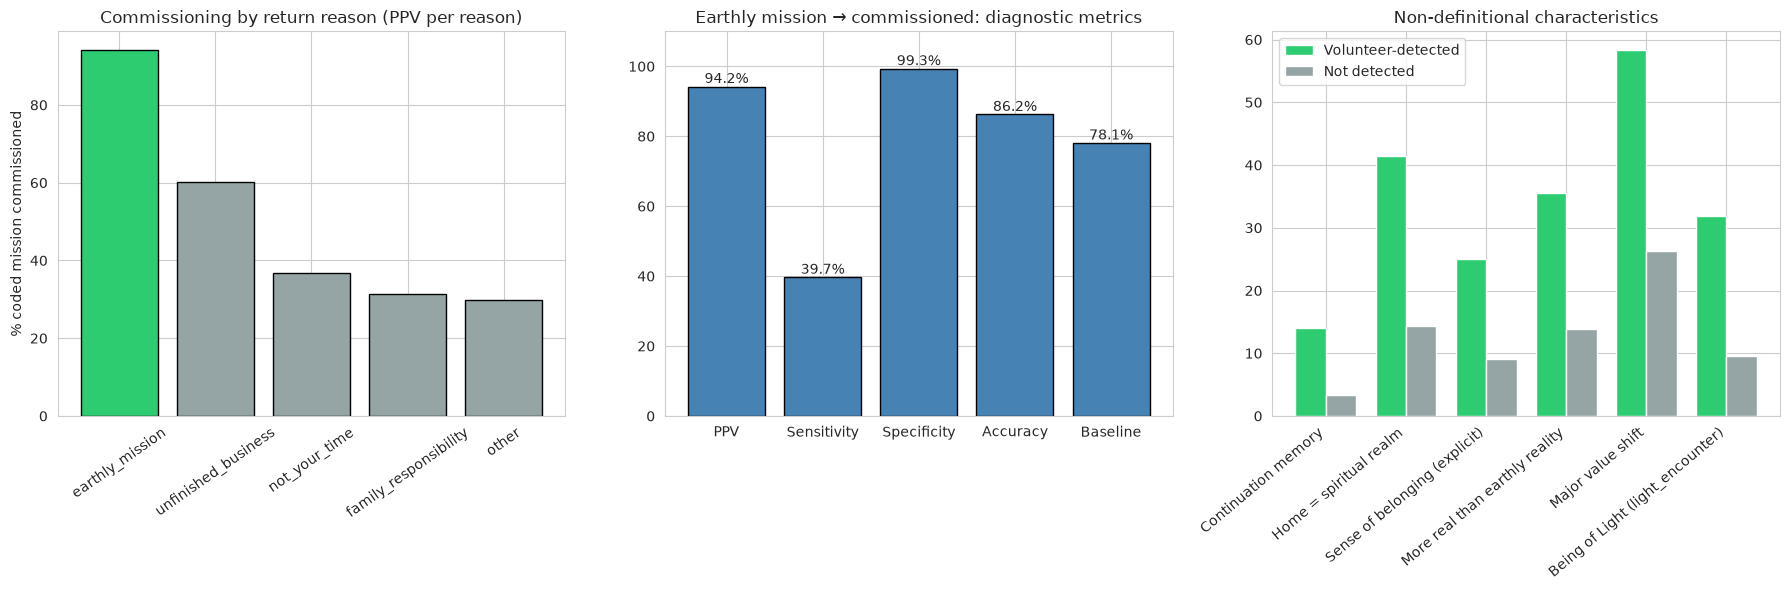

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes[0]
labels = ["earthly_mission", "unfinished_business", "not_your_time", "family_responsibility", "other"]
rates = [100*df.loc[nd.has(df, "return_reasons", r), "commissioned"].mean() for r in labels]
ax.bar(labels, rates, color=["#2ecc71"] + ["#95a5a6"]*4, edgecolor="black"); ax.tick_params(axis="x", rotation=35)
ax.set_ylabel("% coded mission commissioned"); ax.set_title("Commissioning by return reason (PPV per reason)")
ax = axes[1]
vals = [tp/(tp+fp), tp/(tp+fn), tn/(tn+fp), (tp+tn)/N, 1-df.commissioned.mean()]
ax.bar(["PPV", "Sensitivity", "Specificity", "Accuracy", "Baseline"], [100*v for v in vals], color="steelblue", edgecolor="black")
for i, v in enumerate(vals):
    ax.text(i, 100*v + 1, f"{100*v:.1f}%", ha="center")
ax.set_ylim(0, 110); ax.set_title("Earthly mission → commissioned: diagnostic metrics")
ax = axes[2]
ind = profile[profile.status == "independent"]
x = np.arange(len(ind)); w = 0.38
ax.bar(x - w/2, ind["volunteer %"], w, label="Volunteer-detected", color="#2ecc71")
ax.bar(x + w/2, ind["non-volunteer %"], w, label="Not detected", color="#95a5a6")
ax.set_xticks(x); ax.set_xticklabels(ind["characteristic"], rotation=40, ha="right"); ax.legend()
ax.set_title("Non-definitional characteristics")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "volunteer_detection_analysis.png", dpi=150, bbox_inches="tight"); plt.show()

In [12]:
export_cols = ["title", "dataset", "file", "volunteer_detected", "prebirth_indicator_count", "prebirth_awareness", "continuation_memory",
               "earthly_mission", "commissioned", "volunteer_lang", "return_agency", "return_willingness", "mission_commissioned",
               "volunteer_language", "premortal_existence_info", "chose_mission", "chose_parents", "home_is_spiritual",
               "identity_pre_body", "sense_of_belonging", "past_life_memory", "death_memory", "intermission_memory", "word_count"]
df[export_cols].to_csv(OUTPUT_DIR / "volunteer_detection.csv", index=False)
df.loc[vd, export_cols].to_csv(OUTPUT_DIR / "volunteer_detected_cases.csv", index=False)
df.loc[~vd, export_cols].to_csv(OUTPUT_DIR / "non_volunteer_cases.csv", index=False)
print(f"Exported {N:,} rows ({int(vd.sum())} volunteer-detected) to {OUTPUT_DIR}")

Exported 6,751 rows (695 volunteer-detected) to /home/user/structured-data-analysis/projects/nde/output


---
# Summary (corrected)

| Finding | Corrected value | Level of claim |
|---|---|---|
| Earthly-mission reason | 9.2% of NDEs | Descriptive |
| Commissioned given earthly-mission reason (PPV) | 94.2% (95% CI 92.1–95.8) | Descriptive |
| Earthly mission → commissioned, full diagnostics | Sensitivity 39.7%, specificity 99.3%, accuracy 86.2% (baseline 78.1%), κ = 0.49 | "94.2% accuracy" **withdrawn** |
| Volunteer markers detected | 695 (10.3%) | Descriptive (rule-dependent) |
| Pre-birth indicators in volunteer-language accounts (n = 53) | 10–36× elevated, survives length adjustment | Largely definitional overlap |
| Independent characteristics (belonging, spiritual home, hyper-reality, value shift, Being of Light) | Elevated, survive length adjustment | Statistically supported association |
| χ² = 3018 (volunteer × commissioned) | Circular | **Not evidence** |

**Bottom line:** mission-return narratives form an internally coherent cluster that is also associated with several independent NDE features. Because every variable is a model-coded feature of the same retrospective narrative, the data cannot establish that mission commissioning *occurred*, only that it is consistently *reported*.

---
**Notebook**: `03_volunteer_soul_profile.ipynb` · **Schema**: 2026-01-06 · **Audited**: 2026-10-05